In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [2]:
df = pd.read_csv('dataset_1.csv')
df.head()

,area_sqft,bedrooms,age_years,dist_km,price
0,1400.0,2,16,4.93,365516.0
1,1519.0,3,50,7.93,299860.0
2,1290.0,1,0,0.62,353434.0
3,1044.0,3,58,1.75,261079.0
4,1218.0,5,35,0.50,418255.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area_sqft  1200 non-null   float64
 1   bedrooms   1200 non-null   int64  
 2   age_years  1200 non-null   int64  
 3   dist_km    1130 non-null   float64
 4   price      1200 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 47.0 KB


<Axes: ylabel='dist_km'>

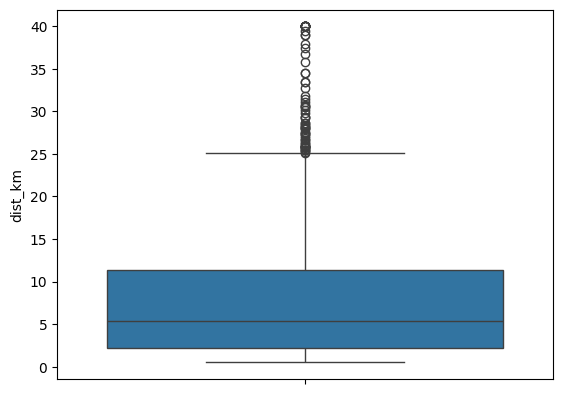

In [4]:
sns.boxplot(df['dist_km'])

In [5]:
fill=df['dist_km'].median().__round__(2)
df['dist_km']=df['dist_km'].fillna(fill)


In [6]:
df

,area_sqft,bedrooms,age_years,dist_km,price
0,1400.0,2,16,4.93,365516.0
1,1519.0,3,50,7.93,299860.0
2,1290.0,1,0,0.62,353434.0
3,1044.0,3,58,1.75,261079.0
4,1218.0,5,35,0.50,418255.0
...,...,...,...,...,...
1195,1855.0,1,52,9.29,301062.0
1196,1956.0,1,19,2.71,423544.0
1197,1342.0,4,22,5.78,412859.0
1198,1330.0,5,4,8.97,425919.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area_sqft  1200 non-null   float64
 1   bedrooms   1200 non-null   int64  
 2   age_years  1200 non-null   int64  
 3   dist_km    1200 non-null   float64
 4   price      1200 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 47.0 KB


In [8]:
X = df.drop(columns=['price'])
y = df['price']

In [9]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, random_state=42, train_size=0.8)

In [10]:
model = LinearRegression()
model.fit(xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
linear_prediction = model.predict(xtest)

In [12]:
# print(prediction.astype(int))

In [13]:
# ytest

In [14]:
# comparision = pd.DataFrame({
#     'Actualdata':ytest.values,
#     'predicted':prediction.round(2)
# })
# comparision.head(100)

In [15]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [16]:
# ypred_train = model.predict(xtrain)

In [17]:
# MAE = mean_absolute_error(ytrain, ypred_train)
# MSE = mean_squared_error(ytrain, ypred_train)
# RMSE = root_mean_squared_error(ytrain, ypred_train)
# score = r2_score(ytrain, ypred_train)

In [18]:
# print(MAE, MSE, RMSE, score)

In [19]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5)
model.fit(xtrain, ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [20]:
prediction = model.predict(xtest)
prediction

array([279335.88      , 446113.8490566 , 118995.61111111, 279335.88      ,
       520406.525     , 279335.88      , 333834.38181818, 367214.66666667,
        42558.6       , 369134.02419355, 369134.02419355, 520406.525     ,
       446693.33333333, 264153.525     , 367214.66666667, 264153.525     ,
       264153.525     , 361555.14285714, 105400.09090909, 456949.66666667,
       369134.02419355, 369134.02419355, 456949.66666667,   4490.4       ,
        43997.66666667, 245543.53333333, 296525.11538462, 188044.83333333,
        43997.66666667, 369134.02419355, 105400.09090909, 456949.66666667,
       245543.53333333, 279335.88      , 456949.66666667, 369134.02419355,
       105400.09090909, 333834.38181818, 456949.66666667, 367214.66666667,
       154224.        , 251124.35714286, 456949.66666667, 279335.88      ,
       446113.8490566 , 446693.33333333, 369134.02419355, 184351.71428571,
       369134.02419355, 446113.8490566 , 333834.38181818, 154224.        ,
       105400.09090909, 1

In [21]:
comparision = pd.DataFrame({
    'Actual_value' : ytest,
    'predicted_value': prediction.round(4)
})

comparision

,Actual_value,predicted_value
1178,140611.0,279335.8800
865,440916.0,446113.8491
101,134529.0,118995.6111
439,284046.0,279335.8800
58,537754.0,520406.5250
...,...,...
382,358240.0,279335.8800
867,289168.0,264153.5250
542,233232.0,279335.8800
1193,573862.0,456949.6667


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(ytest, prediction)

mae

56119.02654460259

In [23]:
linear_mae = mean_absolute_error(ytest, linear_prediction)

linear_mae

24982.402920213586

In [24]:
rscore = r2_score(ytest, prediction)
rscore

0.7208880008225405

In [25]:
linear_rscore = r2_score(ytest, linear_prediction)
linear_rscore

0.9260948573991584

In [26]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

train_scores = []
test_scores = []

In [27]:
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(xtrain, ytrain)

    train_prediction = model.predict(xtrain)
    test_prediction = model.predict(xtest)

    train_r2 = r2_score(ytrain, train_prediction)
    test_r2 = r2_score(ytest, test_prediction)

    train_scores.append(train_r2)
    test_scores.append(test_r2)

In [28]:
print(train_scores, test_scores)

[0.24492630509916236, 0.4855911751451433, 0.6423031570783749, 0.751542079822105, 0.8169700104353796, 0.8743071426156928, 0.9179538548266745, 0.9504670138906812, 0.9726552264375232, 0.9865610766173502] [0.2791257752819216, 0.4488955775237632, 0.5918167073226236, 0.675612317226256, 0.7208880008225405, 0.7695990642999153, 0.8107875808122571, 0.8025189390621588, 0.7798582401664679, 0.7642869249170703]


In [29]:
for depth, train_r2, test_r2 in zip(depths, train_scores, test_scores):
    print(depth, train_r2, test_r2)
    

1 0.24492630509916236 0.2791257752819216
2 0.4855911751451433 0.4488955775237632
3 0.6423031570783749 0.5918167073226236
4 0.751542079822105 0.675612317226256
5 0.8169700104353796 0.7208880008225405
6 0.8743071426156928 0.7695990642999153
7 0.9179538548266745 0.8107875808122571
8 0.9504670138906812 0.8025189390621588
9 0.9726552264375232 0.7798582401664679
10 0.9865610766173502 0.7642869249170703


In [30]:
print(test_scores)

[0.2791257752819216, 0.4488955775237632, 0.5918167073226236, 0.675612317226256, 0.7208880008225405, 0.7695990642999153, 0.8107875808122571, 0.8025189390621588, 0.7798582401664679, 0.7642869249170703]


In [31]:
best_model = DecisionTreeRegressor(max_depth=7)

best_model.fit(xtrain, ytrain)

best_prediction = best_model.predict(xtest)

best_mae = mean_absolute_error(ytest, best_prediction)

print("MAE:", best_mae)

MAE: 45386.13330855118


In [32]:
from sklearn.model_selection import cross_val_score

In [33]:
Dmodel = DecisionTreeRegressor(max_depth=1)

In [34]:
scores = cross_val_score(
    Dmodel,
    X,
    y,
    cv=5,
    scoring="r2"
)
scores

array([0.23006262, 0.22064582, 0.22232999, 0.26127555, 0.28382619])

In [35]:
scores.mean()

0.24362803233643407

In [36]:
cv_scores = []

for depth in range(1, 11):

    model = DecisionTreeRegressor(max_depth=depth)

    scores = cross_val_score(
        model,
        xtrain,
        ytrain,
        cv=5,
        scoring="r2"
    )

    cv_scores.append(scores.mean())

In [37]:
cv_scores

[0.16577094272462373,
 0.42280973402642796,
 0.573579618318432,
 0.6671273564792097,
 0.7084235260125131,
 0.7421377646080966,
 0.7550902997314163,
 0.7630528864333002,
 0.7666629228433636,
 0.7602222493284618]

In [39]:
final_model = DecisionTreeRegressor(max_depth=9)

final_model.fit(xtrain, ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [40]:
final_prediction = final_model.predict(xtest)

In [41]:
final_r2 = r2_score(ytest, final_prediction)
final_mae = mean_absolute_error(ytest, final_prediction)

print("Test R²:", final_r2)
print("MAE:", final_mae)

Test R²: 0.7803794481717501
MAE: 47297.39847528027
